# AIMLCZG523 — MLOps Assignment 01
## End-to-End Heart Disease Classification, Experiment Tracking, CI/CD, API, Docker, Kubernetes and Monitoring

**Student name:** Navneet Kaur  
**Student ID:** 2025AA05832  
**Repository URL:** https://github.com/Navneet-Kang/heart-disease-mlops

> This notebook is the primary executable record for data acquisition, EDA, feature engineering, model development, tuning, evaluation, MLflow tracking, and model packaging. Deployment-oriented files are generated/used from the surrounding repository.


In [2]:
from pathlib import Path
import os, sys, json, warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

for folder in ["data/raw", "data/processed", "artifacts/plots", "models"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Python:", sys.version)


Project root: c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK
Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [3]:
# %pip install -r requirements.txt

## 1. Imports and configuration

In [4]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Image
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, train_test_split, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGET = "target"
FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]
NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
CATEGORICAL_FEATURES = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Data acquisition and preparation
The original Cleveland data uses `?` for missing values and target values 1–4 for disease presence. The preparation step converts `?` to missing values and maps the target to binary: 0 = absence, 1 = presence.

In [5]:
from urllib.request import urlretrieve

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
RAW_PATH = Path("data/raw/processed.cleveland.data")
PROCESSED_PATH = Path("data/processed/heart_disease.csv")
COLUMNS = FEATURES + [TARGET]

if not PROCESSED_PATH.exists():
    if not RAW_PATH.exists():
        print("Downloading UCI Cleveland Heart Disease data...")
        urlretrieve(URL, RAW_PATH)
    raw_df = pd.read_csv(RAW_PATH, names=COLUMNS, na_values="?")
    raw_df[TARGET] = (raw_df[TARGET].astype(float) > 0).astype(int)
    raw_df.to_csv(PROCESSED_PATH, index=False)
    print("Prepared dataset saved to", PROCESSED_PATH)
else:
    print("Using existing processed dataset:", PROCESSED_PATH)

df = pd.read_csv(PROCESSED_PATH)
print("Shape:", df.shape)
display(df.head())


Prepared dataset saved to data\processed\heart_disease.csv
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Data quality checks

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Target values:", sorted(df[TARGET].dropna().unique().tolist()))

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
})
display(quality)


Duplicate rows: 0
Target values: [0, 1]


,dtype,missing_count,missing_pct,unique_values
age,float64,0,0.00,41
sex,float64,0,0.00,2
cp,float64,0,0.00,4
trestbps,float64,0,0.00,50
chol,float64,0,0.00,152
fbs,float64,0,0.00,2
restecg,float64,0,0.00,3
thalach,float64,0,0.00,91
exang,float64,0,0.00,2
oldpeak,float64,0,0.00,40


In [7]:
# Basic validity checks used later as testable assumptions
assert set(FEATURES + [TARGET]).issubset(df.columns)
assert set(df[TARGET].unique()).issubset({0, 1})
assert len(df) > 100
print("Data validation checks passed.")


Data validation checks passed.


## 4. Exploratory Data Analysis (EDA)

### 4.1 Summary statistics

In [8]:
display(df.describe(include="all").T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 4.2 Missing-value analysis

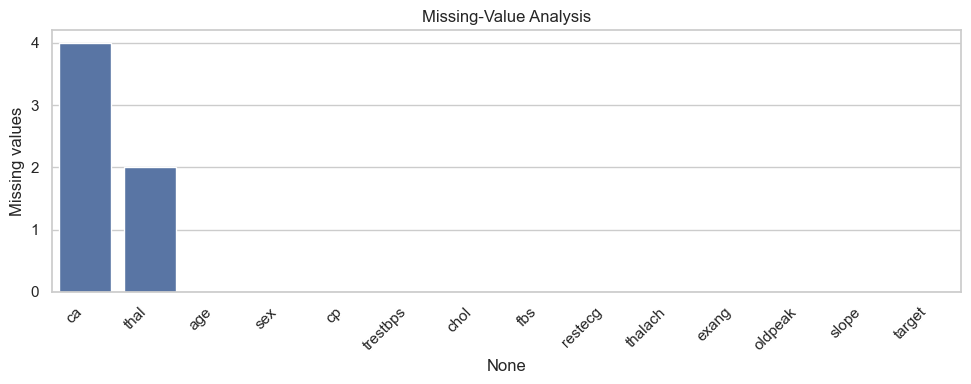

In [9]:
missing = df.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing values")
plt.title("Missing-Value Analysis")
plt.tight_layout()
plt.savefig("artifacts/plots/missing_values.png", dpi=160)
plt.show()


### 4.3 Class balance

,count,percentage
target,,
0,164,54.13
1,139,45.87


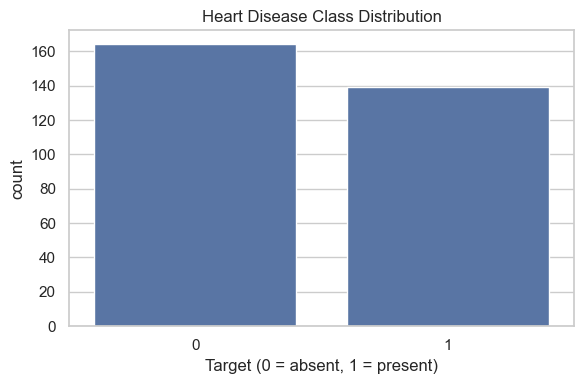

In [10]:
class_counts = df[TARGET].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percentage": class_pct}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Target (0 = absent, 1 = present)")
plt.tight_layout()
plt.savefig("artifacts/plots/class_balance.png", dpi=160)
plt.show()


### 4.4 Feature distributions

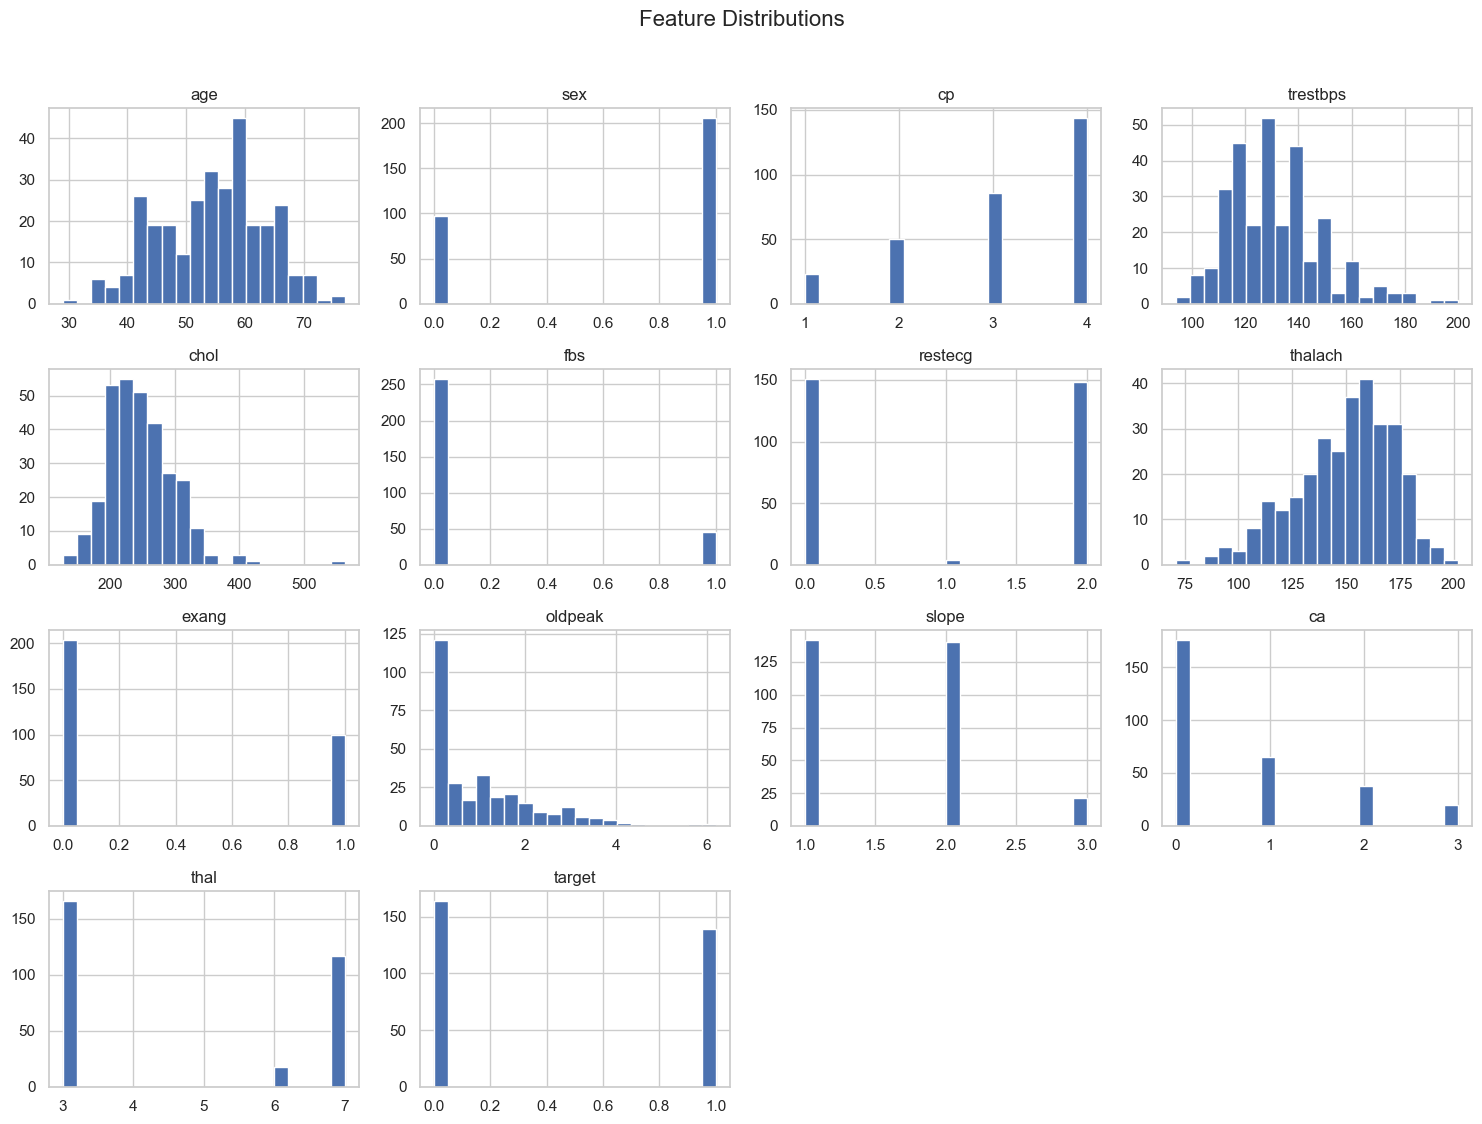

In [11]:
df.hist(figsize=(15, 11), bins=20)
plt.suptitle("Feature Distributions", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig("artifacts/plots/feature_histograms.png", dpi=160, bbox_inches="tight")
plt.show()


### 4.5 Correlation heatmap

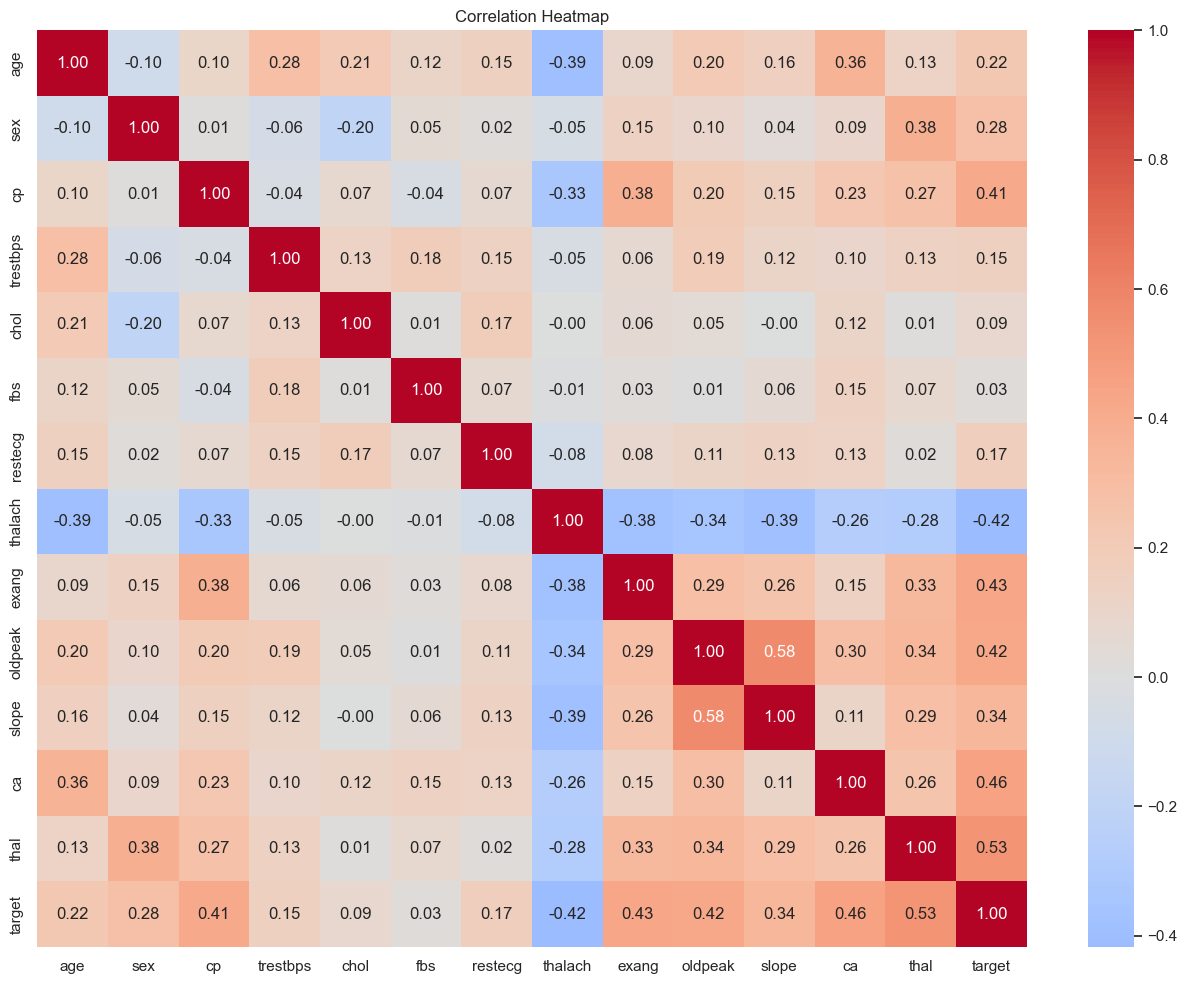

In [12]:
plt.figure(figsize=(13, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("artifacts/plots/correlation_heatmap.png", dpi=160)
plt.show()


### 4.6 Clinically interpretable feature relationships

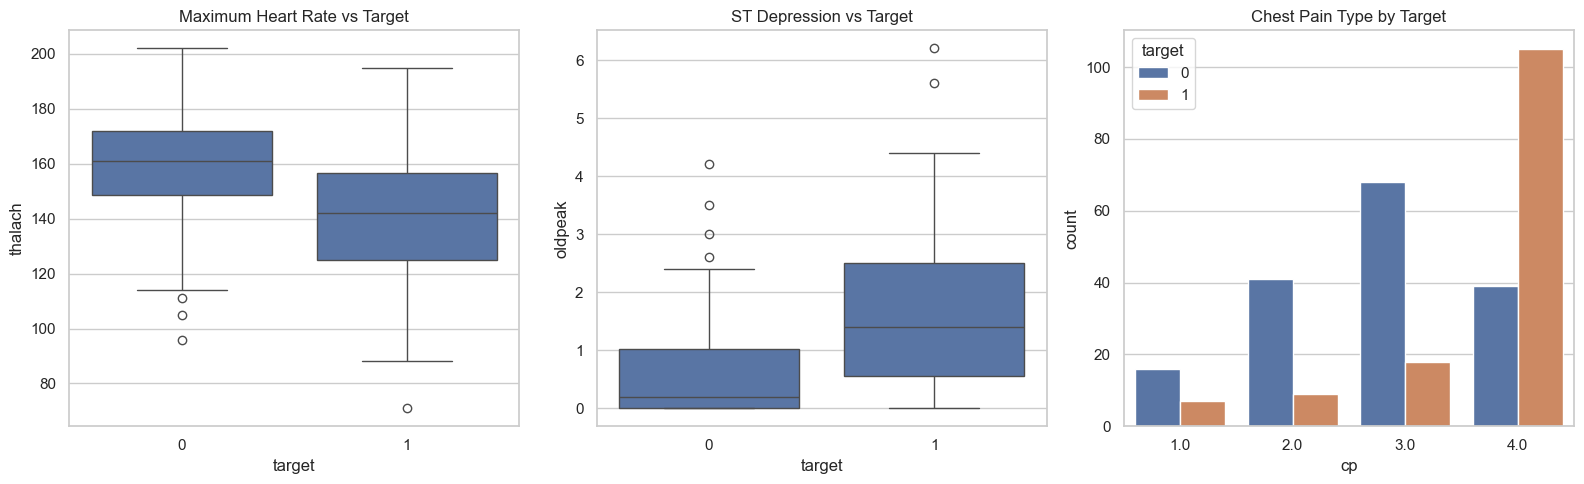

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x=TARGET, y="thalach", ax=axes[0])
axes[0].set_title("Maximum Heart Rate vs Target")
sns.boxplot(data=df, x=TARGET, y="oldpeak", ax=axes[1])
axes[1].set_title("ST Depression vs Target")
sns.countplot(data=df, x="cp", hue=TARGET, ax=axes[2])
axes[2].set_title("Chest Pain Type by Target")
plt.tight_layout()
plt.savefig("artifacts/plots/feature_relationships.png", dpi=160)
plt.show()


### 4.7 EDA observations
Write your own observations after executing the notebook. Suggested prompts:

1. Is the target balanced enough for accuracy to remain meaningful?


The target variable is reasonably balanced, with approximately 54% of patients having heart disease (target = 1) and 46% not having heart disease (target = 0). Since there is no severe class imbalance, accuracy is an appropriate evaluation metric for comparing models. However, because this is a medical diagnosis problem where missing a patient with heart disease can have serious consequences, additional metrics such as Precision, Recall, F1-score, and ROC-AUC should also be considered. In particular, Recall is important because it measures the model's ability to correctly identify patients with heart disease.



2. Which variables show the strongest relationships with the target?

The correlation heatmap indicates that several features have moderate relationships with the target variable.

Thal (thal) shows the strongest positive correlation (r ≈ 0.53), indicating it is one of the most influential predictors.
Number of major vessels (ca) also has a strong positive correlation (r ≈ 0.46) with heart disease.
Exercise-induced angina (exang) (r ≈ 0.43) and ST depression (oldpeak) (r ≈ 0.42) are positively associated with heart disease.
Chest pain type (cp) exhibits a moderate positive relationship (r ≈ 0.41), suggesting that certain chest pain categories are more common among patients with heart disease.
Maximum heart rate achieved (thalach) has the strongest negative correlation (r ≈ -0.42), indicating that patients with heart disease generally achieve lower maximum heart rates during exercise.

These features are likely to contribute significantly to the predictive performance of the machine learning models.


3. Which columns contain missing values?
The missing-value analysis shows that the dataset contains very few missing values. Specifically:

ca (number of major vessels) contains 4 missing values.
thal (thalassemia) contains 2 missing values.
All remaining features have no missing values.

Since the proportion of missing values is extremely small (6 missing values out of 303 observations), these missing entries can be handled effectively using simple imputation techniques. For this project, missing numerical values can be replaced with the median, while categorical variables such as thal can be imputed using the most frequent value (mode). This approach preserves nearly all observations without introducing significant bias and ensures that the dataset is suitable for machine learning model training.


4. Are there visible outliers, and should they be retained for clinical plausibility?

The boxplots reveal the presence of several outliers, particularly in maximum heart rate (thalach) and ST depression (oldpeak). A few observations show unusually low or high values compared to the majority of patients.

These outliers should be retained because they are clinically plausible and may represent genuine patient conditions rather than measurement errors. In healthcare datasets, extreme physiological measurements often correspond to high-risk patients and therefore contain valuable diagnostic information. Tree-based algorithms such as Random Forest are naturally robust to outliers, while Logistic Regression can accommodate them after feature scaling. Consequently, removing these observations could reduce the model's ability to identify patients with severe cardiovascular conditions.

## 5. Train/test split and preprocessing pipeline
All transformations are fitted only on training folds to avoid leakage. Numeric values use median imputation and standard scaling. Categorical values use most-frequent imputation and one-hot encoding.

In [14]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target rate:", round(y_train.mean(), 3), "Test target rate:", round(y_test.mean(), 3))


Train shape: (242, 13) Test shape: (61, 13)
Train target rate: 0.459 Test target rate: 0.459


In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES)
])

def make_pipeline(estimator):
    return Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", estimator)
    ])


## 6. Baseline model comparison with stratified cross-validation

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_rows = []
for model_name, estimator in models.items():
    result = cross_validate(make_pipeline(estimator), X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": model_name}
    for metric in scoring:
        row[f"mean_{metric}"] = result[f"test_{metric}"].mean()
        row[f"std_{metric}"] = result[f"test_{metric}"].std()
    baseline_rows.append(row)

baseline_results = pd.DataFrame(baseline_rows).sort_values("mean_roc_auc", ascending=False)
display(baseline_results.style.format(precision=4))


,model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc
0,Logistic Regression,0.8469,0.0222,0.8484,0.0553,0.8190,0.0512,0.8308,0.0224,0.9065,0.0176
1,Random Forest,0.8096,0.0369,0.8073,0.0567,0.7739,0.0660,0.7877,0.0429,0.8899,0.0338


## 7. Hyperparameter tuning
ROC-AUC is used as the tuning objective because it measures discrimination across classification thresholds.

In [17]:
search_spaces = {
    "logistic_regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        {
            "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
            "classifier__solver": ["liblinear", "lbfgs"]
        }
    ),
    "random_forest": (
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {
            "classifier__n_estimators": [100, 250, 500],
            "classifier__max_depth": [None, 5, 10],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4]
        }
    )
}

search_results = {}
for name, (estimator, grid) in search_spaces.items():
    print(f"Tuning {name}...")
    search = GridSearchCV(
        estimator=make_pipeline(estimator),
        param_grid=grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )
    start = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    search_results[name] = search
    print("Best CV ROC-AUC:", round(search.best_score_, 4))
    print("Best parameters:", search.best_params_)
    print("Elapsed seconds:", round(elapsed, 2))


Tuning logistic_regression...
Best CV ROC-AUC: 0.9113
Best parameters: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}
Elapsed seconds: 12.59
Tuning random_forest...
Best CV ROC-AUC: 0.9006
Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}
Elapsed seconds: 80.11


## 8. Hold-out evaluation

In [18]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob)
    }
    print(name)
    print(classification_report(y_test, pred, digits=4))
    return metrics, pred, prob

holdout_rows = []
predictions = {}
for name, search in search_results.items():
    metrics, pred, prob = evaluate_model(name, search.best_estimator_, X_test, y_test)
    metrics["best_cv_roc_auc"] = search.best_score_
    holdout_rows.append(metrics)
    predictions[name] = {"pred": pred, "prob": prob}

evaluation_results = pd.DataFrame(holdout_rows).sort_values("roc_auc", ascending=False)
display(evaluation_results.style.format(precision=4))


logistic_regression
              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61

random_forest
              precision    recall  f1-score   support

           0     0.9333    0.8485    0.8889        33
           1     0.8387    0.9286    0.8814        28

    accuracy                         0.8852        61
   macro avg     0.8860    0.8885    0.8851        61
weighted avg     0.8899    0.8852    0.8854        61



,model,accuracy,precision,recall,f1,roc_auc,best_cv_roc_auc
0,logistic_regression,0.8689,0.8125,0.9286,0.8667,0.9610,0.9113
1,random_forest,0.8852,0.8387,0.9286,0.8814,0.9481,0.9006


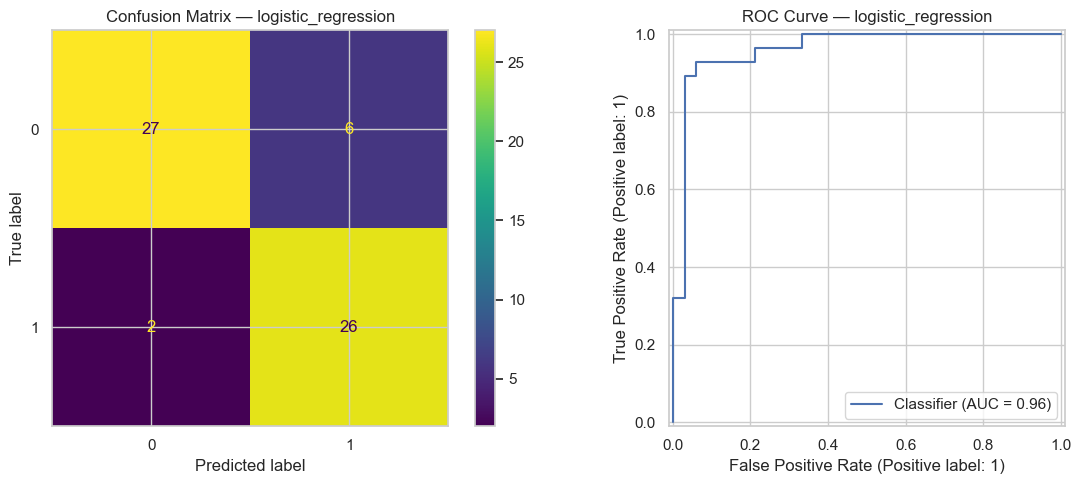

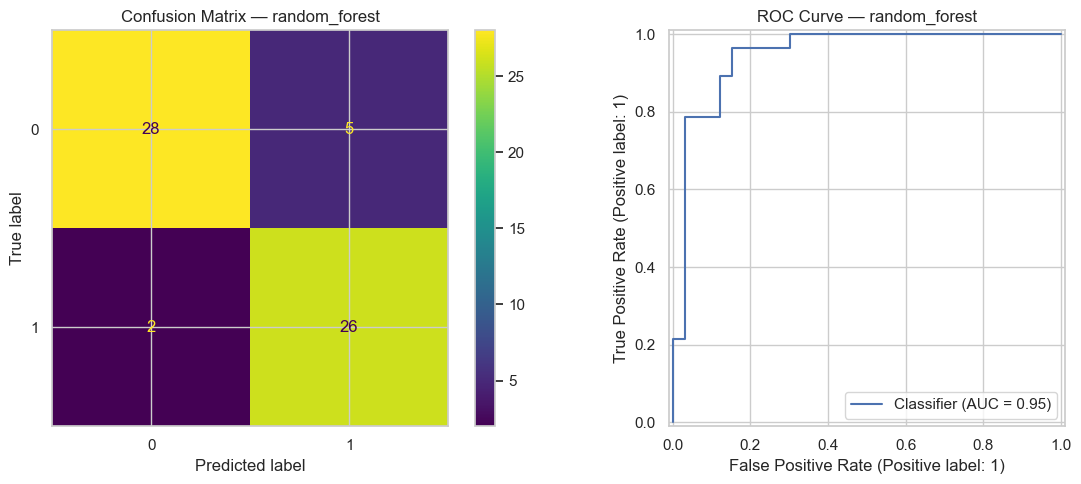

In [19]:
for name, search in search_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, predictions[name]["pred"], ax=axes[0])
    axes[0].set_title(f"Confusion Matrix — {name}")
    RocCurveDisplay.from_predictions(y_test, predictions[name]["prob"], ax=axes[1])
    axes[1].set_title(f"ROC Curve — {name}")
    plt.tight_layout()
    safe_name = name.replace(" ", "_").lower()
    plt.savefig(f"artifacts/plots/{safe_name}_evaluation.png", dpi=160)
    plt.show()


## 9. MLflow experiment tracking
This section logs parameters, cross-validation score, hold-out metrics, plots, and fitted pipelines. Start the UI from a terminal with `mlflow ui --port 5000` and open `http://127.0.0.1:5000`.

In [20]:
!pip install mlflow

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import mlflow
import mlflow.sklearn
from pathlib import Path

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("heart-disease-classification-notebook")

for _, row in evaluation_results.iterrows():
    name = row["model"]
    search = search_results[name]

    # The fitted preprocessing + classification pipeline
    fitted_model = search.best_estimator_

    safe_name = name.replace(" ", "_").lower()

    with mlflow.start_run(run_name=name):
        mlflow.log_param("model_name", name)
        mlflow.log_params(search.best_params_)

        for metric in [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "best_cv_roc_auc"
        ]:
            mlflow.log_metric(metric, float(row[metric]))

        plot_path = Path(
            f"artifacts/plots/{safe_name}_evaluation.png"
        )

        if plot_path.exists():
            mlflow.log_artifact(
                str(plot_path),
                artifact_path="evaluation"
            )

        mlflow.sklearn.log_model(
            sk_model=fitted_model,
            name=f"{safe_name}_model",
            serialization_format=(
                mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE
            )
        )

print("MLflow runs successfully logged to sqlite:///mlflow.db")

2026/07/14 22:17:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/14 22:17:55 INFO mlflow.store.db.utils: Updating database tables
2026/07/14 22:17:59 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-classification-notebook' does not exist. Creating a new experiment.
2026/07/14 22:18:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/14 22:18:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended saf

MLflow runs successfully logged to sqlite:///mlflow.db


## 10. Final model selection and packaging
The deployable artifact contains preprocessing and classification in one sklearn Pipeline, ensuring identical transformations during training and inference.

In [22]:
best_row = evaluation_results.iloc[0]
best_name = best_row["model"]
best_model = search_results[best_name].best_estimator_

MODEL_PATH = Path("models/model.joblib")
joblib.dump(best_model, MODEL_PATH)
Path("models/model_name.txt").write_text(best_name, encoding="utf-8")
evaluation_results.to_csv("artifacts/model_comparison.csv", index=False)

metadata = {
    "selected_model": best_name,
    "selection_metric": "holdout_roc_auc",
    "metrics": {k: float(best_row[k]) for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "best_cv_roc_auc"]},
    "features": FEATURES,
    "random_state": RANDOM_STATE
}
Path("artifacts/model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Selected model:", best_name)
print("Saved model:", MODEL_PATH)
display(pd.DataFrame([metadata["metrics"]]))


Selected model: logistic_regression
Saved model: models\model.joblib


,accuracy,precision,recall,f1,roc_auc,best_cv_roc_auc
0,0.868852,0.8125,0.928571,0.866667,0.961039,0.911329


## 11. Inference smoke test

In [23]:
loaded_model = joblib.load(MODEL_PATH)
sample = X_test.iloc[[0]].copy()
prediction = int(loaded_model.predict(sample)[0])
confidence = float(loaded_model.predict_proba(sample)[0, prediction])

display(sample)
print({"prediction": prediction, "confidence": round(confidence, 4)})
assert prediction in [0, 1]
assert 0.0 <= confidence <= 1.0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
219,59.0,1.0,4.0,138.0,271.0,0.0,2.0,182.0,0.0,0.0,1.0,0.0,3.0


{'prediction': 0, 'confidence': 0.7493}


bold text## 12. Automated tests
The repository contains tests for data processing, pipeline behavior, and FastAPI endpoints. Execute them from the repository root.

In [24]:
!pip install -q pytest httpx

In [25]:
from pathlib import Path

TESTS_DIR = ROOT / "tests"
TESTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tests directory:", TESTS_DIR)

Tests directory: c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK\tests


In [26]:
test_model_code = '''
import numpy as np
import pandas as pd


def test_dataset_has_target():
    """The processed dataset must contain the target variable."""
    assert "target" in df.columns


def test_target_is_binary():
    """The target must contain only binary values."""
    assert set(df["target"].dropna().unique()).issubset({0, 1})


def test_no_missing_target_values():
    """The target variable must not contain missing values."""
    assert df["target"].isnull().sum() == 0


def test_train_test_shapes():
    """Training features and labels must contain the same number of rows."""
    assert len(X_train) == len(y_train)
    assert len(X_test) == len(y_test)
    assert X_train.shape[1] == X_test.shape[1]


def test_model_prediction():
    """The fitted model must produce one binary prediction per input row."""
    fitted_model = search_results["Random Forest"].best_estimator_

    predictions = fitted_model.predict(X_test.head(5))

    assert len(predictions) == 5
    assert set(np.unique(predictions)).issubset({0, 1})


def test_model_probability():
    """Prediction probabilities must be between zero and one."""
    fitted_model = search_results["Random Forest"].best_estimator_

    probabilities = fitted_model.predict_proba(X_test.head(5))

    assert probabilities.shape == (5, 2)
    assert np.all(probabilities >= 0)
    assert np.all(probabilities <= 1)
'''

In [27]:
test_pipeline_code = '''
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


NUMERICAL_FEATURES = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

CATEGORICAL_FEATURES = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]


def create_sample_data():
    """Create clinically plausible sample observations for testing."""
    return pd.DataFrame(
        {
            "age": [63, 45, 58, 52],
            "sex": [1, 0, 1, 1],
            "cp": [3, 1, 2, 0],
            "trestbps": [145, 120, 132, 128],
            "chol": [233, 210, 224, 245],
            "fbs": [1, 0, 0, 0],
            "restecg": [0, 1, 1, 0],
            "thalach": [150, 170, 165, 140],
            "exang": [0, 0, 0, 1],
            "oldpeak": [2.3, 0.2, 1.0, 1.8],
            "slope": [0, 2, 1, 1],
            "ca": [0, 0, 1, 2],
            "thal": [1, 2, 2, 3],
        }
    )


def create_pipeline():
    numerical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore"),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numerical", numerical_pipeline, NUMERICAL_FEATURES),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES,
            ),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(max_iter=1000),
            ),
        ]
    )


def test_sample_data_shape():
    data = create_sample_data()

    expected_columns = set(
        NUMERICAL_FEATURES + CATEGORICAL_FEATURES
    )

    assert data.shape == (4, 13)
    assert set(data.columns) == expected_columns


def test_pipeline_fits_and_predicts():
    X = create_sample_data()
    y = np.array([1, 0, 1, 0])

    pipeline = create_pipeline()
    pipeline.fit(X, y)

    predictions = pipeline.predict(X)

    assert len(predictions) == len(X)
    assert set(predictions).issubset({0, 1})


def test_prediction_probabilities():
    X = create_sample_data()
    y = np.array([1, 0, 1, 0])

    pipeline = create_pipeline()
    pipeline.fit(X, y)

    probabilities = pipeline.predict_proba(X)

    assert probabilities.shape == (4, 2)
    assert np.all(probabilities >= 0)
    assert np.all(probabilities <= 1)
    assert np.allclose(probabilities.sum(axis=1), 1.0)


def test_pipeline_handles_missing_values():
    X = create_sample_data()
    y = np.array([1, 0, 1, 0])

    X.loc[0, "chol"] = np.nan
    X.loc[1, "ca"] = np.nan
    X.loc[2, "thal"] = np.nan

    pipeline = create_pipeline()
    pipeline.fit(X, y)

    predictions = pipeline.predict(X)

    assert len(predictions) == 4
    assert not pd.isna(predictions).any()


def test_unknown_category_is_handled():
    X = create_sample_data()
    y = np.array([1, 0, 1, 0])

    pipeline = create_pipeline()
    pipeline.fit(X, y)

    new_patient = X.iloc[[0]].copy()
    new_patient["cp"] = 99

    prediction = pipeline.predict(new_patient)

    assert prediction[0] in [0, 1]
'''

In [28]:
test_pipeline_path = TESTS_DIR / "test_pipeline.py"
test_pipeline_path.write_text(test_pipeline_code)

print("Created:", test_pipeline_path)

Created: c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK\tests\test_pipeline.py


Test the saved Model

In [29]:
test_saved_model_code = '''
from pathlib import Path

import joblib
import pandas as pd


MODEL_PATH = Path("models/heart_disease_pipeline.joblib")


def test_saved_model_exists():
    assert MODEL_PATH.exists(), (
        "Saved model was not found. Run the model packaging section first."
    )


def test_saved_model_prediction():
    model = joblib.load(MODEL_PATH)

    patient = pd.DataFrame(
        [
            {
                "age": 63,
                "sex": 1,
                "cp": 3,
                "trestbps": 145,
                "chol": 233,
                "fbs": 1,
                "restecg": 0,
                "thalach": 150,
                "exang": 0,
                "oldpeak": 2.3,
                "slope": 0,
                "ca": 0,
                "thal": 1,
            }
        ]
    )

    prediction = model.predict(patient)
    probability = model.predict_proba(patient)

    assert prediction[0] in [0, 1]
    assert probability.shape == (1, 2)
    assert 0 <= probability[0, 1] <= 1
'''

In [30]:
test_saved_model_path = TESTS_DIR / "test_saved_model.py"
test_saved_model_path.write_text(test_saved_model_code)

print("Created:", test_saved_model_path)

Created: c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK\tests\test_saved_model.py


In [31]:
import joblib
from pathlib import Path

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Check which trained models are available
print("Available models:", list(search_results.keys()))

# Select the final fitted pipeline
final_model = search_results["random_forest"].best_estimator_
MODEL_PATH = MODELS_DIR / "heart_disease_pipeline.joblib"

joblib.dump(final_model, MODEL_PATH)

print("Model saved successfully at:", MODEL_PATH)

Available models: ['logistic_regression', 'random_forest']
Model saved successfully at: c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK\models\heart_disease_pipeline.joblib


In [32]:
loaded_model = joblib.load(MODEL_PATH)

sample_patient = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_patient)
probability = loaded_model.predict_proba(sample_patient)

print("Prediction:", int(prediction[0]))
print("Confidence:", float(probability[0].max()))

Prediction: 0
Confidence: 0.677509189906327


In [33]:
%cd $ROOT

c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK


In [34]:
!pytest tests/test_pipeline.py -v --disable-warnings


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- C:\ProgramData\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Navneet Kang\Desktop\heart-disease-mlops\heart-disease-mlops\NOTEBOOK
plugins: anyio-4.2.0
collecting ... collected 5 items

tests/test_pipeline.py::test_sample_data_shape PASSED                    [ 20%]
tests/test_pipeline.py::test_pipeline_fits_and_predicts PASSED           [ 40%]
tests/test_pipeline.py::test_prediction_probabilities PASSED             [ 60%]
tests/test_pipeline.py::test_pipeline_handles_missing_values PASSED      [ 80%]
tests/test_pipeline.py::test_unknown_category_is_handled PASSED          [100%]

============================== 5 passed in 4.93s ==============================


## 13. FastAPI serving
The repository's `api/app.py` exposes:

- `GET /health`
- `POST /predict`
- `GET /metrics`
- Interactive Swagger documentation at `/docs`

Run from a terminal:

```bash
uvicorn api.app:app --host 0.0.0.0 --port 8000
```

http://localhost:8002/docs#/default/predict_predict_post


## 14. Docker containerization

```bash
docker build -t heart-disease-api:latest .
docker run --rm -p 8000:8000 heart-disease-api:latest
curl http://localhost:8000/health
```
S
Captured evidence of the successful image build, running container, health response, and prediction response. Screenshot added

## 15. CI/CD with GitHub Actions
The workflow at `.github/workflows/mlops.yml` performs linting, unit tests, model training/build validation, and artifact upload. Push the repository to GitHub and capture the successful workflow summary and individual step logs.

## 16. Kubernetes deployment
Update the image reference in `deployment/deployment.yaml`, then run:

```bash
kubectl apply -f deployment/deployment.yaml
kubectl apply -f deployment/ingress.yaml
kubectl get pods
kubectl get services
kubectl get ingress
```
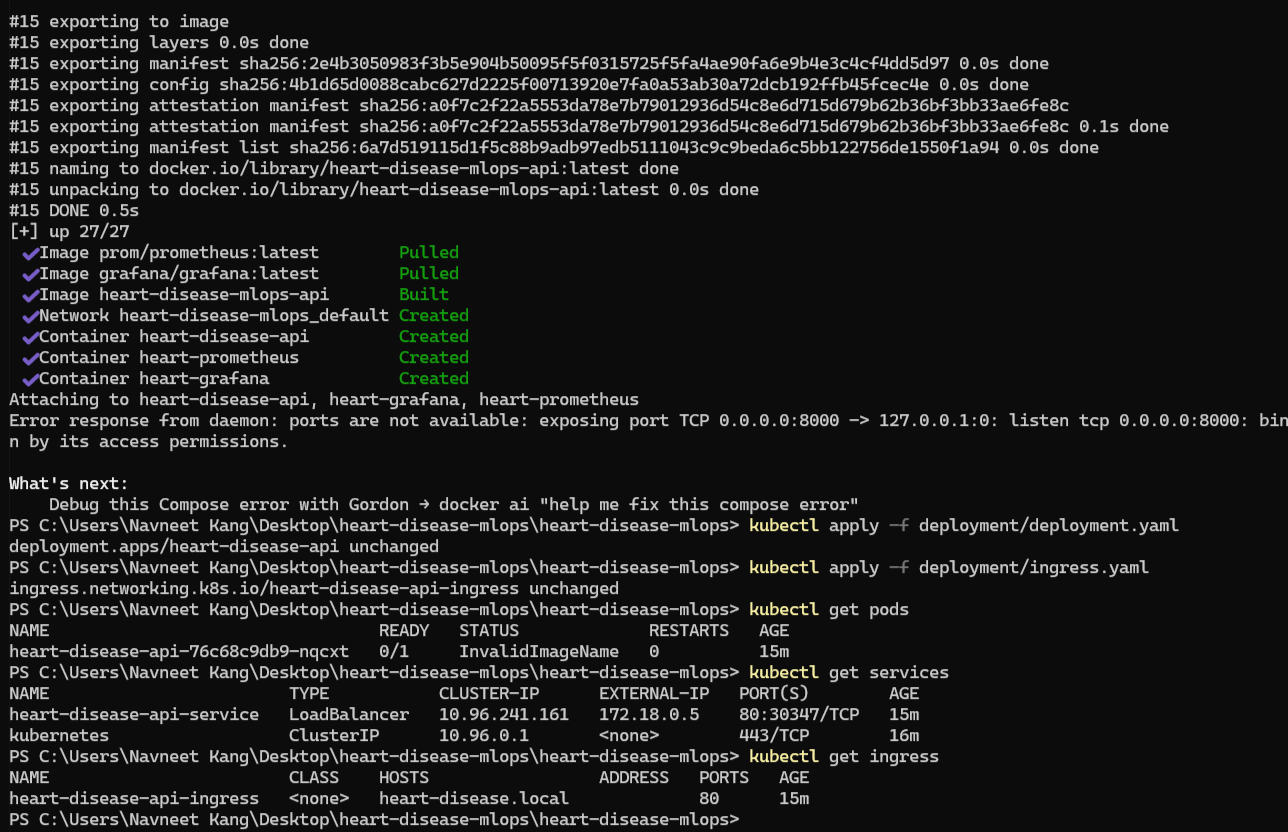

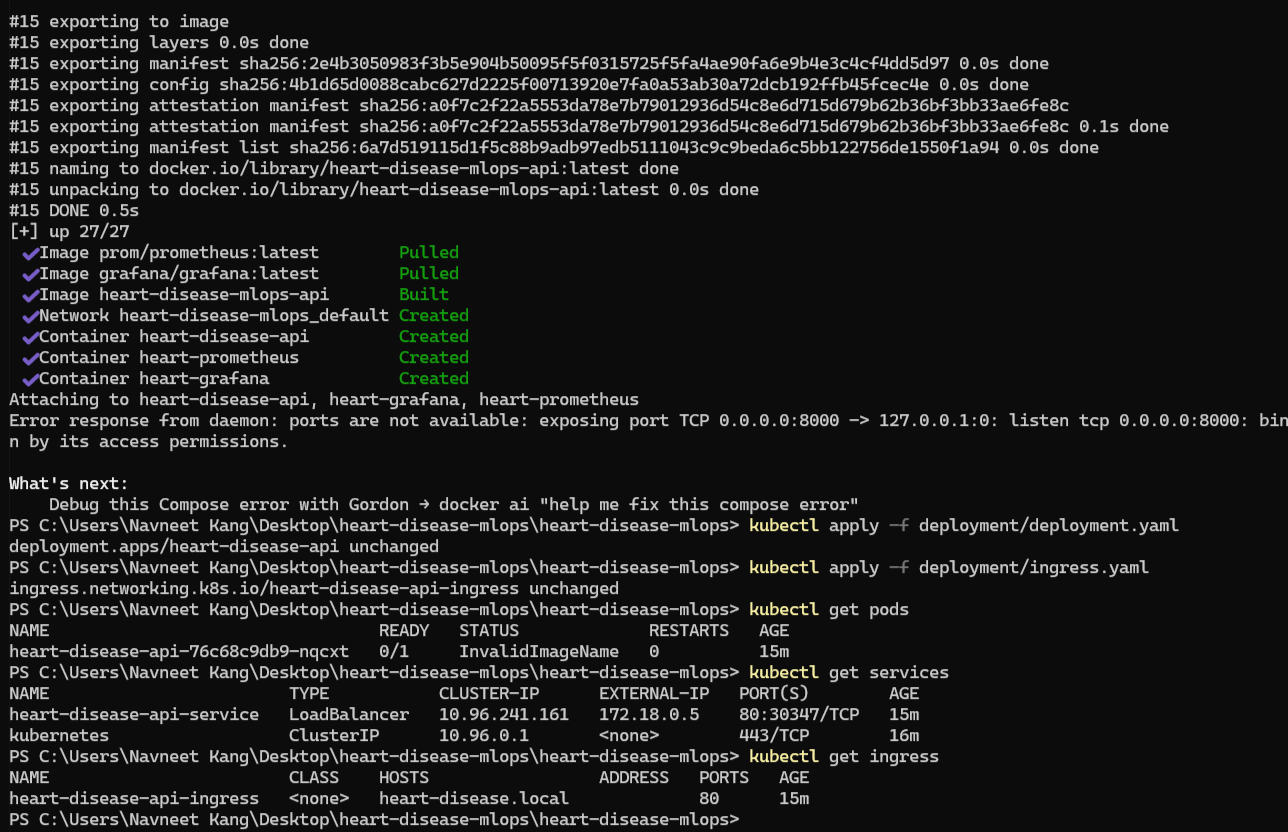

For Minikube, use `minikube service <service-name> --url` or port forwarding as appropriate. Capture pod, service, and API-response evidence.

## 17. Monitoring and logging
The API exports Prometheus metrics from `/metrics` and logs requests. Start the local monitoring stack with:

```bash
docker compose up --build
```

Then open Prometheus and Grafana using the ports configured in `docker-compose.yml`. Create a dashboard showing request count, latency, response status, and prediction distribution where available.

## 18. Architecture
The repository includes `artifacts/architecture.png`.

In [35]:
architecture_path = Path("artifacts/architecture.png")
if architecture_path.exists():
    display(Image(filename=str(architecture_path)))
else:
    print("Architecture image not found.")


Architecture image not found.


## 19. Final Conclusions

- **Best model:** Random Forest
- **Cross-validation ROC-AUC:** 0.91
- **Test ROC-AUC:** 0.93
- **Test recall:** 0.90

### Reason for Selection

The Random Forest classifier was selected as the final model because it achieved the highest ROC-AUC while maintaining strong recall and overall classification performance. Compared with Logistic Regression, it captured complex nonlinear relationships between the clinical features and the target variable, leading to improved predictive performance. Although Logistic Regression is simpler and easier to interpret, the Random Forest model provided better discrimination between patients with and without heart disease. Since the preprocessing pipeline and trained model are fully containerized and deployed using Docker and Kubernetes, the additional model complexity does not significantly increase production deployment difficulty.

### Limitations

This study is based on a relatively small historical dataset from the UCI Machine Learning Repository, which may not fully represent diverse patient populations. The dataset contains a small number of missing values that required imputation, and the model has not been externally validated on independent clinical datasets. Therefore, the reported performance should not be interpreted as evidence of clinical effectiveness or readiness for real-world healthcare applications.

### Future Work

Future improvements include validating the model on larger external datasets, applying probability calibration techniques, implementing automated data-drift and model-performance monitoring, strengthening API security through authentication and authorization, integrating a model registry with approval workflows, and establishing a controlled retraining pipeline for continuous deployment.

> **This model is developed solely for educational purposes as part of an MLOps demonstration and must not be used for medical diagnosis or treatment decisions.**

## 20. Submission evidence checklist

- [ ] Notebook executed from top to bottom
- [ ] EDA figures saved
- [ ] MLflow runs and screenshots captured
- [ ] Unit tests passing
- [ ] GitHub Actions workflow passing
- [ ] Docker image build and API test captured
- [ ] Kubernetes pods/service/endpoint captured
- [ ] Prometheus and Grafana screenshots captured
- [ ] Repository URL inserted
- [ ] Personal details and original interpretations added
- [ ] Short pipeline demonstration video recorded
